### Measurement
Measurement begins with recording the ISSW-measured intensity of light when a filter paper contains LAI (for *light-absorbing impurity*), and $I_0$ when a filter is clean (see Eq. 1 of Grenfell et al, 2011, Eq. 1). Then the *absorption optical depth* is given by

$$
\chi_\lambda = log({I_0 \over I}) \ \ \ (1)
$$

where Here, we'll focus on $\lambda_1=450 \ nm$ and $\lambda_2=600 \ nm$). We can use the absorption optical depth to compute an *instrumental optical depth*, $f_{instr}$, according to a version (the inverse) of Grenfell et al's Eq. 4,

$$
f_{instr}(R_\lambda,\chi_\lambda) = {1\over2}ln \bigl( (1-R_\lambda) \times exp(\chi_\lambda)+((1-R_\lambda)^2 \times exp(2\chi_\lambda)+4R_\lambda) \bigr) \ \ \ (2)
$$

where $R_\lambda \equiv R_1R_2(\lambda)$ is the wavelength-dependent product of reflectivities of the two integrating spheres of the ISSW; other instrument-specific parameters are the size of the ISSW aperture and the intensity of the light source. Properties of the millipore filter paper itself also affect $f_{instr}$. We account for these effects via the factor $\kappa_\lambda$,

$$
\tau_\lambda  = f_{instr} \times \kappa_\lambda \ \ \ (3)
$$

Values of $\kappa_\lambda$ and $R_\lambda$ must be determined by a calibration procedure (described below). Once known, however, we can compute the LAI loading, 

$$
L_{ISSW} = {\tau_\lambda \over \beta_{\lambda,std}}  \ \ \ (4)
$$

where $\beta_{\lambda,std}$ is the *mass absorption cross section*, also referred to as *MAC*, of a standard LAI. For a fullerene standard, these values are $\beta_{450,fullerene}=8.9 \ m^2/g$ and $\beta_{600,fullerene}=6.5 \ m^2/g$, consistent with $Å=1.09$. We can also use ratios of optical depths produced by Eq. 3 to calculate an LAI's's *absorption Angstrom exponent*,

$$
Å = -{log(\tau_{450}/\tau_{600}) \over log(\lambda_{450}/\lambda_{600})} \ \ \ (5)
$$

where (because of the proportionality in Eq. 3) we could also use $-{log(\tau'_{450}/\tau'_{600}) \over log(\lambda_{450}/\lambda_{600})}$ to achieve the same result.

### Calibration
The goal of calibration is to obtain values of $R_{450}$, $R_{600}$, $\kappa_{450}$ and $\kappa_{600}$. The process relies on ISSW-measured intensities ($I$) of a set of filter papers with varying loadings ($L_{ISSW}$) of a standard LAI (fullerene) ... that minimize the sum of squared differences between $\tau_\lambda$(obs) and $\tau_\lambda$(theory). We'll need the inverse of Eq. 2 (which is Grenfell et al's Eq. 4),

$$
\chi_\lambda = 2 f_\lambda + ln \bigl ({1 - R e^{-4 f_\lambda}   \over 1 - R}    \bigr ) \ \ \ (6)
$$

... We should note that this procedure also takes into account a difference in units, namely, that $L_{ISSW}$ has units ${\mu g \over cm^2}$, while $L_{LAHM}$ has units $\mu g$.


**References**

Grenfell, T. C., Doherty, S. J., Clarke, A. D., & Warren, S. G. (2011). Light absorption from particulate impurities in snow and ice determined by spectrophotometric analysis of filters. Applied Optics, 50(14), 2037-2048.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from importlib import reload  # Python 3.4+
import ISSWlib as IS; reload(IS)
%matplotlib inline

### Fullerene standard on millipore filters

In [2]:
# Load the standard ISSW spectra

spectrum_folder = 'UPS_INKStandards/'; filtertype_std = 'nucleopore'
subset_start = 0
subset_stop = -1

# spectrum_folder = 'Ulyana ful/'; filtertype = 'millipore'
# subset_start = 0
# subset_stop = -2


In [3]:
spectrum_filelist = spectrum_folder+'spectrum_files.txt'
spectrum_list, number_of_loadings = IS.get_spectrum_list(spectrum_filelist)

From getline0list: In  UPS_INKStandards/spectrum_files.txt , finding these spectra:
      B.10mL.txt
      A.14mL.txt
      C.20mL.txt
      C.34mL.txt
      C.50mL.txt
      C.57mL.txt


lambda_450 =  450.0
lambda_600 =  600.0
[0.10675694 0.13786454 0.35274588 0.61801001 0.96510315]
[0.07533085 0.10553502 0.31159369 0.57764665 0.91957422]
Length of L_range =  5
Number of loadings =  5


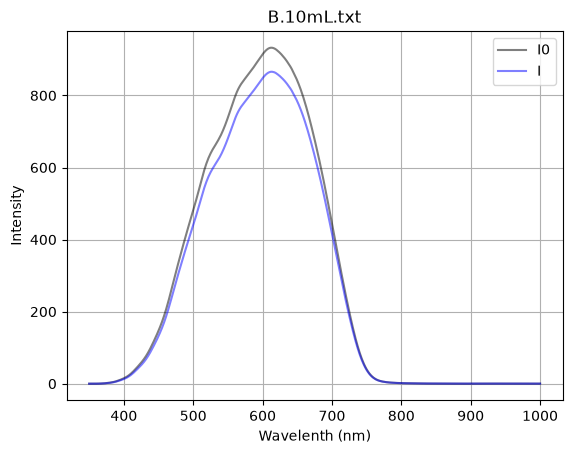

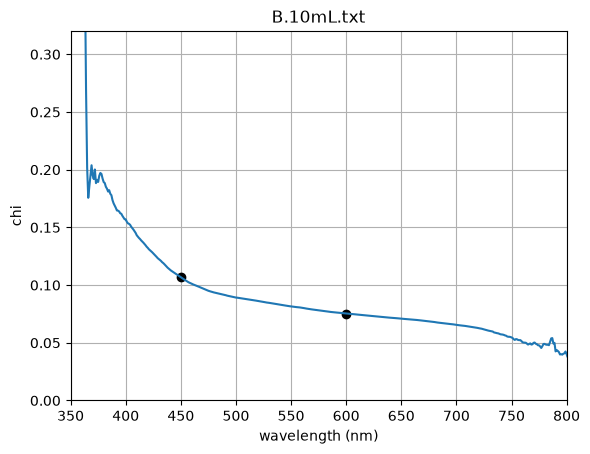

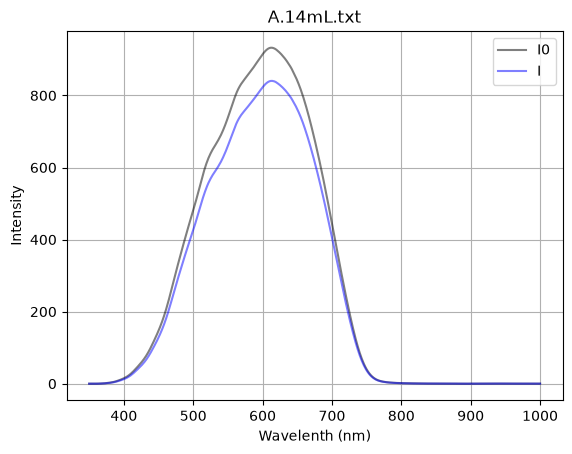

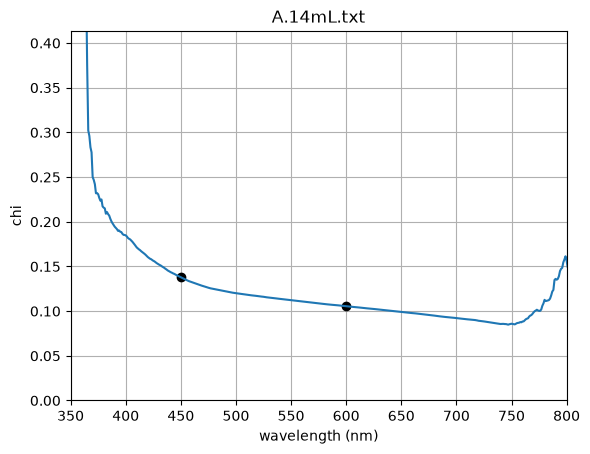

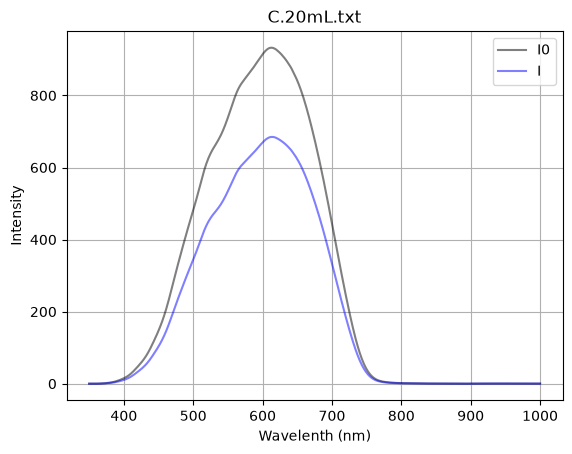

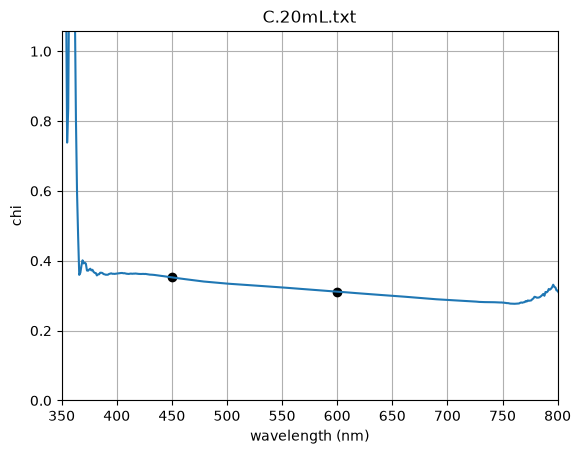

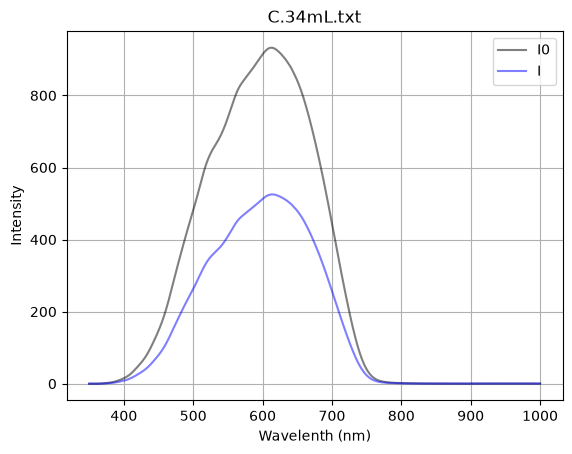

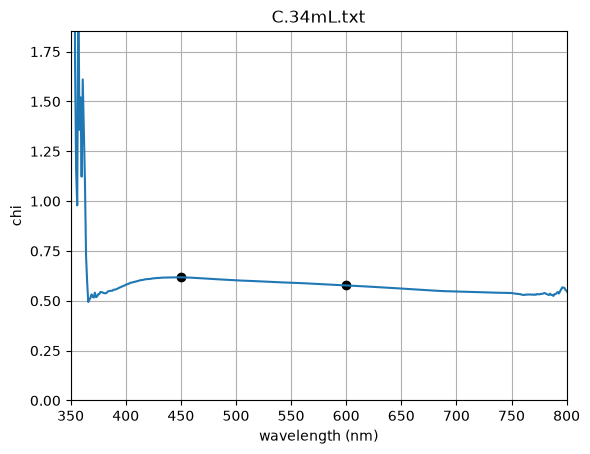

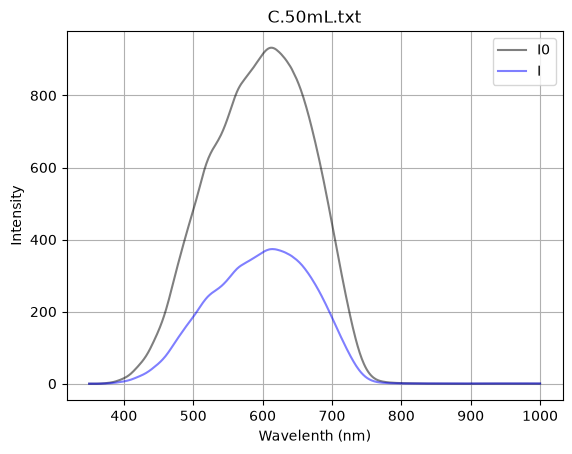

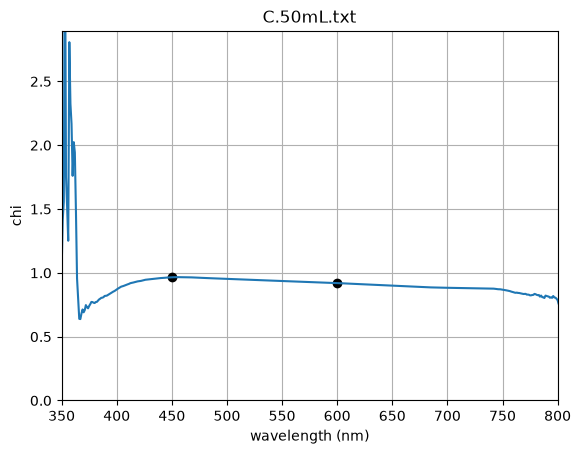

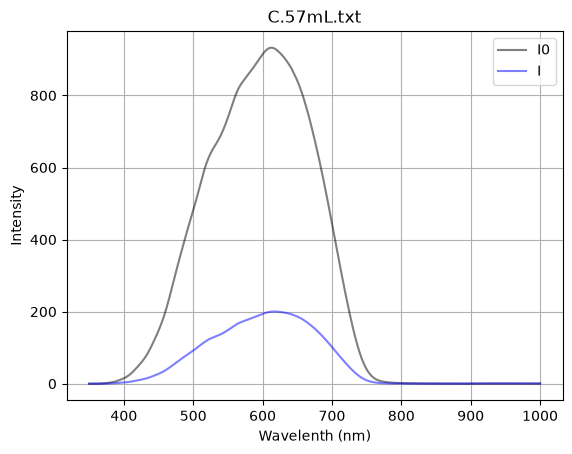

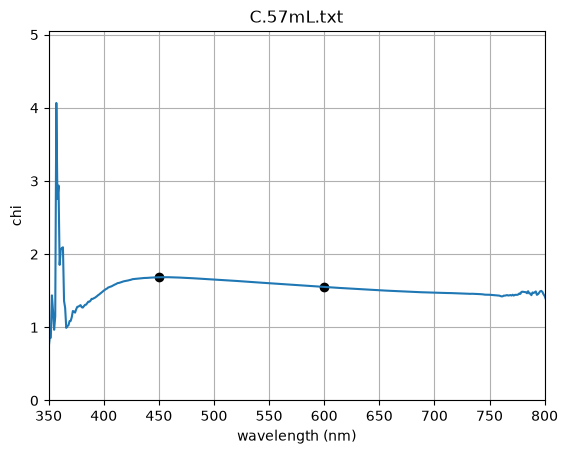

In [4]:
# Load in the blank, and check indices
lambda_nm, I0_raw = IS.get_spectrum(spectrum_folder+'/Blank.txt')
I_450 = 100; print('lambda_450 = ',lambda_nm[I_450])
I_600 = 250; print('lambda_600 = ',lambda_nm[I_600])

# Preallocate arrays
chi_range_450 = np.zeros(number_of_loadings)
chi_range_600 = np.zeros(number_of_loadings)

# Get the chi-values
for i in range(number_of_loadings):
    
    # Extract the spectrum for this item in the list
    spectrum_filename = spectrum_list[i]
    lambda_nm, I_raw = IS.get_spectrum(spectrum_folder+spectrum_filename)
    
    # Smooth and shift
    I, I0 = IS.smooth_and_shift(I_raw,I0_raw)
    
    # Get observed chi
    chi = IS.get_chi_obs(I,I0,lambda_nm, title=spectrum_filename)
    
    # Save chi values at lambda1 and lambda2
    chi_range_450[i] = chi[I_450]
    chi_range_600[i] = chi[I_600]

chi_range_450 = chi_range_450[subset_start:subset_stop]; print(chi_range_450)
chi_range_600 = chi_range_600[subset_start:subset_stop]; print(chi_range_600)
number_of_loadings = np.size(chi_range_450)

# Loading values on samples and their optical depths
L_range = np.array([0.55, 0.86, 3.02, 6.34, 11.8, 25.4]) # This is in microgram/cm^2
L_range = L_range[subset_start:subset_stop]

# Double-checking
print('Length of L_range = ', len(L_range))
print('Number of loadings = ', number_of_loadings)
if len(L_range) != number_of_loadings:
    print('inconsistency')
    np.sqrt(-1)

### Using a best-fit line to get $\chi$(L) and L($\chi$)

betabar_450 =  0.06223193147969459
betabar_600 =  0.05498244495094332
AAE_std from chi slopes =  0.4305248611059947


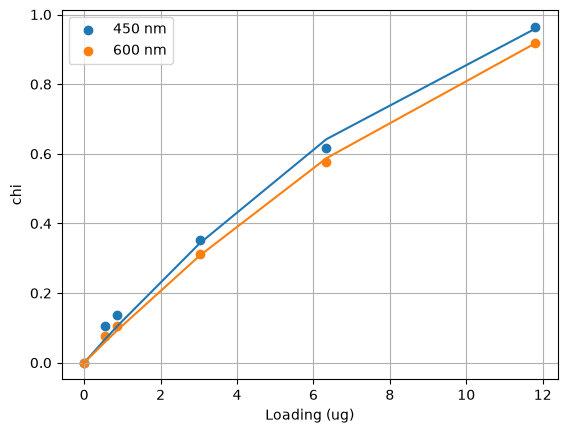

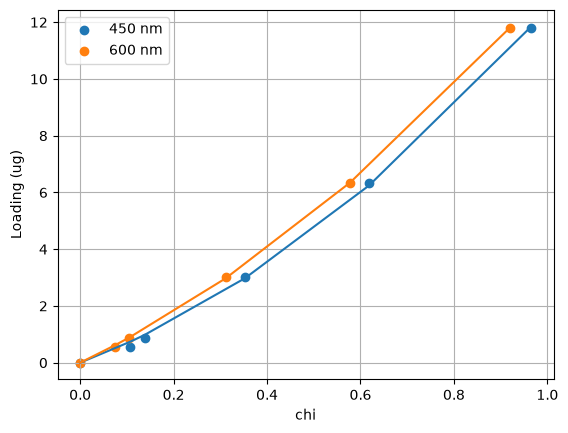

In [5]:
# Fitting chi(L)
L_range_extended = np.append(0,L_range)
chi_range_450_extended = np.append(0,chi_range_450)
chi_range_600_extended = np.append(0,chi_range_600)
weights = np.ones(np.shape(L_range_extended)); weights[0] = 100
p_chi_450 = np.polyfit(L_range_extended,chi_range_450_extended,2,w=weights)
p_chi_600 = np.polyfit(L_range_extended,chi_range_600_extended,2,w=weights)

# Let's take a look at chi(L)
plt.figure()
plt.scatter(L_range_extended,chi_range_450_extended,marker='o',label='450 nm')
plt.scatter(L_range_extended,chi_range_600_extended,marker='o',label='600 nm')
plt.xlabel('Loading (ug)')
plt.ylabel('chi')
plt.legend()
plt.plot(L_range_extended,np.polyval(p_chi_450,L_range_extended))
plt.plot(L_range_extended,np.polyval(p_chi_600,L_range_extended))
plt.grid(True)

# Fitting L(chi)
p_L_450 = np.polyfit(chi_range_450_extended,L_range_extended,2,w=weights)
p_L_600 = np.polyfit(chi_range_600_extended,L_range_extended,2,w=weights)

# Let's take a look at L(chi)
plt.figure()
plt.scatter(chi_range_450_extended,L_range_extended,marker='o',label='450 nm')
plt.scatter(chi_range_600_extended,L_range_extended,marker='o',label='600 nm')
plt.xlabel('chi')
plt.ylabel('Loading (ug)')
plt.legend()
plt.plot(chi_range_450_extended,np.polyval(p_L_450,chi_range_450_extended))
plt.plot(chi_range_600_extended,np.polyval(p_L_600,chi_range_600_extended))
plt.grid(True)

# betabar ... the factor of 1/2 is because of Tom's eq. 4
this_difference = 0
betabar_450 = p_chi_450[-2]/2; print('betabar_450 = ', betabar_450)
betabar_600 = p_chi_600[-2]/2; print('betabar_600 = ', betabar_600)

# AAE
AAE = (-np.log(betabar_450/betabar_600)/np.log(450/600))
print('AAE_std from chi slopes = ', AAE)

### Pretending this is a retrieval

LAHM loading, std-equivalent @450, 600, AAE =  B.10mL.txt 0.55 0.7366226688409885 0.6231264614734315 1.012161008856737
LAHM loading, std-equivalent @450, 600, AAE =  A.14mL.txt 0.86 0.9781001238293923 0.8901987414684958 0.7578559918843515
LAHM loading, std-equivalent @450, 600, AAE =  C.20mL.txt 3.02 2.9768240667575996 2.975290798670599 0.43231573085005076
LAHM loading, std-equivalent @450, 600, AAE =  C.34mL.txt 6.34 6.240964900202435 6.346201163792117 0.3723996190578408
LAHM loading, std-equivalent @450, 600, AAE =  C.50mL.txt 11.8 11.841684385354812 11.801797919606596 0.44225307083394555


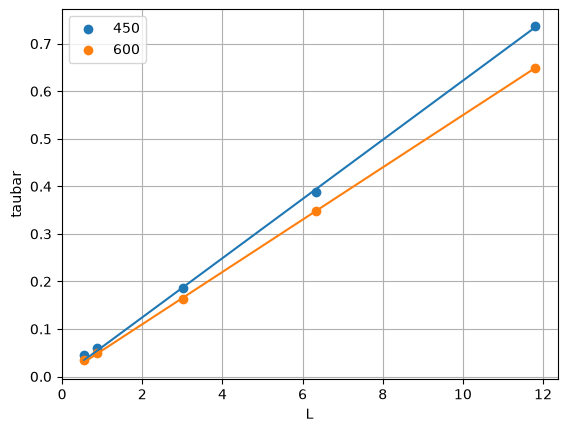

In [6]:
# Now, pretending this is a retrieval ... we already have chi_range_450 and chi_range_600
chi_450_obs = chi_range_450
chi_600_obs = chi_range_600

betabar_450_std = betabar_450
betabar_600_std = betabar_600
AAE_std = AAE

# Reduced optical depths
taubar_450_obs = betabar_450_std*np.polyval(p_L_450,chi_450_obs)
taubar_600_obs = betabar_600_std*np.polyval(p_L_600,chi_600_obs)
taubar_450_theory = betabar_450_std*L_range
taubar_600_theory = betabar_600_std*L_range

plt.figure()
plt.scatter(L_range,taubar_450_obs,label='450')
plt.scatter(L_range,taubar_600_obs,label='600')
plt.grid(True)
plt.legend()
plt.plot(L_range,taubar_450_theory)
plt.plot(L_range,taubar_600_theory)
plt.xlabel('L')
plt.ylabel('taubar')

# Get the AAE implied by these optical depths
AAE_obs = -np.log(taubar_450_obs/taubar_600_obs)/np.log(450/600)

# Assuming the standard's beta values, get equivalent loadings
L_450_equiv = taubar_450_obs/betabar_450_std
L_600_equiv = taubar_600_obs/betabar_600_std

# Report out
for j in range(number_of_loadings):
    print('LAHM loading, std-equivalent @450, 600, AAE = ', spectrum_list[j], L_range[j], L_450_equiv[j], L_600_equiv[j], AAE_obs[j])

In [7]:
# Saving parameters
parameter_filename = 'calibration IV parameters ('+filtertype_std+ ') (July 22, 2026).csv'
calibration_spectrum_folder = spectrum_folder
Save_parameter_flag = True
if Save_parameter_flag:

    print('Saving the parameter file:')
    print(parameter_filename)
    data = {
    "calibration_spectrum_folder": [calibration_spectrum_folder],
    "betabar_450_std": [betabar_450_std],
    "betabar_600_std": [betabar_600_std],
    "filtertype_std": [filtertype_std],
    "p_L_450": [p_L_450],
    "p_L_600": [p_L_600],
    "AAE_std": [AAE_std]
    }
    df = pd.DataFrame(data)
    
    # Display the DataFrame
    print(df)

    df.to_csv(parameter_filename, index=False)

Saving the parameter file:
calibration IV parameters (nucleopore) (July 22, 2026).csv
  calibration_spectrum_folder  betabar_450_std  betabar_600_std  \
0           UPS_INKStandards/         0.062232         0.054982   

  filtertype_std                                            p_L_450  \
0     nucleopore  [6.255862295020168, 6.232332702941912, -2.0419...   

                                             p_L_600   AAE_std  
0  [5.40369812816501, 7.8648865863139426, -6.6615...  0.430525  


In [8]:
# # This is just a test that the inversion is correct
# print(chi_range_450)
# f_range_450 = IS.get_f(chi_range_450,R_450_best); print(f_range_450)
# chi_test = IS.get_chi_theory(f_range_450,R_450_best); print(chi_test)